# Lesson 3: Optuna Hyperparameter Search


Самостоятельный ноутбук для автоматического подбора гиперпараметров через Optuna, сохранения результатов, модели и повторной проверки после загрузки.


In [1]:
from __future__ import annotations

import json
from datetime import datetime
from pathlib import Path
from typing import Any, cast

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from IPython import get_ipython
from IPython.display import display
from optuna.trial import TrialState
from sklearn.datasets import load_digits
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score
from sklearn.model_selection import train_test_split

from students.kudryavcev.lesson3 import Exercise, Layer, LinearLayer, Model


In [2]:
PROJECT_DIR = Path("students/kudryavcev/lesson3")
RESULTS_DIR = PROJECT_DIR / "results"
MODELS_DIR = PROJECT_DIR / "models/auto"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
FINAL_SEED = 2026
N_CLASSES = 10


In [3]:
digits = load_digits()
X = digits.data.astype(np.float32)
y = digits.target.astype(np.int64)

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_val,
)

mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0] = 1.0

X_train_norm = (X_train - mean) / std
X_val_norm = (X_val - mean) / std
X_test_norm = (X_test - mean) / std
X_trainval_norm = np.vstack([X_train_norm, X_val_norm])
y_trainval = np.concatenate([y_train, y_val])

print(
    f"Dataset split: train={len(X_train)}, val={len(X_val)}, test={len(X_test)}"
)


Dataset split: train=1077, val=360, test=360


In [4]:
def build_model(
    hidden_layers: list[tuple[int, str]],
    *,
    input_dim: int,
    output_dim: int,
    seed: int,
) -> Model:
    rng = np.random.default_rng(seed)
    layers: list[Layer] = []
    current_dim = input_dim

    for units, activation in hidden_layers:
        layers.append(Exercise.create_linear_layer(current_dim, units, rng))
        if activation == "relu":
            layers.append(Exercise.create_relu_layer())
        elif activation == "sigmoid":
            layers.append(Exercise.create_sigmoid_layer())
        else:
            raise ValueError(f"Unsupported activation: {activation}")
        current_dim = units

    layers.append(Exercise.create_linear_layer(current_dim, output_dim, rng))
    return Exercise.create_model(*layers)


def predict_classes(model: Model, x: np.ndarray) -> np.ndarray:
    logits = model.forward(x)
    return np.argmax(logits, axis=1)


def evaluate_accuracy(model: Model, x: np.ndarray, y_true: np.ndarray) -> float:
    y_pred = predict_classes(model, x)
    return float(accuracy_score(y_true, y_pred))


def sanitize_name(value: str) -> str:
    chars: list[str] = []
    for char in value:
        if char.isalnum() or char in {'-', '_'}:
            chars.append(char)
        else:
            chars.append('_')
    return ''.join(chars)


def format_architecture_name(hidden_layers: list[tuple[int, str]]) -> str:
    parts = [f"{units}{activation[0]}" for units, activation in hidden_layers]
    return f"{len(hidden_layers)}L_" + '_'.join(parts)


def make_model_path(
    prefix: str,
    arch_name: str,
    *,
    lr: float,
    batch_size: int,
    epochs: int,
    accuracy: float,
) -> Path:
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename = (
        f"{timestamp}_{sanitize_name(prefix)}_{sanitize_name(arch_name)}_"
        f"lr{lr:g}_bs{batch_size}_ep{epochs}_acc{accuracy:.4f}.npz"
    )
    return MODELS_DIR / filename


def save_model_bundle(
    model: Model,
    filepath: Path,
    *,
    arch_name: str,
    config: list[tuple[int, str]],
    mean_vector: np.ndarray,
    std_vector: np.ndarray,
) -> None:
    payload: dict[str, Any] = {
        'arch_name': np.array(arch_name),
        'config': np.array(json.dumps(config)),
        'mean': mean_vector.astype(np.float32),
        'std': std_vector.astype(np.float32),
    }

    linear_idx = 0
    for layer in model.layers:
        if isinstance(layer, LinearLayer):
            payload[f'weight_{linear_idx}'] = layer.weights
            payload[f'bias_{linear_idx}'] = layer.bias
            linear_idx += 1

    np.savez(str(filepath), **payload)
    print(f"Saved model to {filepath}")


def load_model_bundle(filepath: Path, *, seed: int = 0) -> tuple[Model, dict[str, Any]]:
    data = np.load(filepath, allow_pickle=False)
    arch_name = str(data['arch_name'])
    config_raw = cast(list[list[Any]], json.loads(str(data['config'])))
    config = [(int(units), str(activation)) for units, activation in config_raw]
    mean_vector = data['mean'].astype(np.float32)
    std_vector = data['std'].astype(np.float32)

    model = build_model(
        config,
        input_dim=int(mean_vector.shape[0]),
        output_dim=N_CLASSES,
        seed=seed,
    )

    linear_idx = 0
    for layer in model.layers:
        if isinstance(layer, LinearLayer):
            layer.weights = data[f'weight_{linear_idx}'].astype(np.float32)
            layer.bias = data[f'bias_{linear_idx}'].astype(np.float32)
            linear_idx += 1

    metadata: dict[str, Any] = {
        'arch_name': arch_name,
        'config': config,
        'mean': mean_vector,
        'std': std_vector,
    }
    return model, metadata


def plot_confusion(y_true: np.ndarray, y_pred: np.ndarray, *, title: str) -> None:
    fig, ax = plt.subplots(figsize=(7, 7))
    ConfusionMatrixDisplay.from_predictions(y_true, y_pred, ax=ax, cmap='Blues')
    ax.set_title(title)
    plt.tight_layout()
    if get_ipython() is not None:
        display(fig)
    plt.close(fig)


In [5]:
AUTO_TRIALS_CSV = RESULTS_DIR / 'auto_trials.csv'
AUTO_BEST_JSON = RESULTS_DIR / 'auto_best.json'
AUTO_DB_PATH = RESULTS_DIR / 'lesson3_auto_search_v1.db'
AUTO_STORAGE = f"sqlite:///{AUTO_DB_PATH.resolve().as_posix()}"

SEARCH_SEED = 42
N_TRIALS = 24
MAX_EPOCHS = 80
PATIENCE = 12

optuna.logging.set_verbosity(optuna.logging.WARNING)


def train_one_epoch(
    model: Model,
    *,
    loss: Any,
    x: np.ndarray,
    y_true: np.ndarray,
    lr: float,
    batch_size: int,
    rng: np.random.Generator,
) -> None:
    indices = rng.permutation(x.shape[0])

    for start in range(0, x.shape[0], batch_size):
        batch_idx = indices[start:start + batch_size]
        x_batch = x[batch_idx]
        y_batch = y_true[batch_idx]

        logits = model.forward(x_batch)
        loss_value = float(loss.forward(logits, y_batch))
        if not np.isfinite(loss_value):
            raise FloatingPointError('Non-finite loss detected')

        gradients = loss.backward()
        model.backward(gradients)

        for param, grad in zip(model.parameters, model.grad, strict=True):
            if not np.all(np.isfinite(grad)):
                raise FloatingPointError('Non-finite gradient detected')
            param -= lr * grad


def snapshot_parameters(model: Model) -> list[np.ndarray]:
    return [parameter.copy() for parameter in model.parameters]


def restore_parameters(model: Model, parameters: list[np.ndarray]) -> None:
    for current, saved in zip(model.parameters, parameters, strict=True):
        current[...] = saved


def fit_with_early_stopping(
    hidden_layers: list[tuple[int, str]],
    *,
    lr: float,
    batch_size: int,
    seed: int,
    max_epochs: int,
    patience: int,
    trial: optuna.Trial | None = None,
) -> float:
    rng = np.random.default_rng(seed)
    model = build_model(
        hidden_layers,
        input_dim=int(X_train_norm.shape[1]),
        output_dim=N_CLASSES,
        seed=seed,
    )
    loss = Exercise.create_cross_entropy_loss()
    best_score = -np.inf
    best_state = snapshot_parameters(model)
    epochs_without_improvement = 0

    for epoch in range(max_epochs):
        train_one_epoch(
            model,
            loss=loss,
            x=X_train_norm,
            y_true=y_train,
            lr=lr,
            batch_size=batch_size,
            rng=rng,
        )
        val_accuracy = evaluate_accuracy(model, X_val_norm, y_val)

        if trial is not None:
            trial.report(val_accuracy, step=epoch)
            if trial.should_prune():
                raise optuna.TrialPruned() from None

        if val_accuracy > best_score:
            best_score = val_accuracy
            best_state = snapshot_parameters(model)
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= patience:
            break

    restore_parameters(model, best_state)
    return float(best_score)


def suggest_hidden_layers(trial: optuna.Trial) -> list[tuple[int, str]]:
    n_layers = int(trial.suggest_int('n_layers', 1, 3))
    hidden_layers: list[tuple[int, str]] = []
    for layer_idx in range(n_layers):
        units_choice = trial.suggest_categorical(
            f'units_{layer_idx}',
            [16, 32, 64, 128, 256],
        )
        activation_choice = trial.suggest_categorical(
            f'activation_{layer_idx}',
            ['relu', 'sigmoid'],
        )
        units = int(units_choice)
        activation = str(activation_choice)
        hidden_layers.append((units, activation))
    return hidden_layers


def hidden_layers_from_params(params: dict[str, Any]) -> list[tuple[int, str]]:
    n_layers = int(cast(int, params['n_layers']))
    hidden_layers: list[tuple[int, str]] = []
    for layer_idx in range(n_layers):
        units = int(cast(int, params[f'units_{layer_idx}']))
        activation = str(cast(str, params[f'activation_{layer_idx}']))
        hidden_layers.append((units, activation))
    return hidden_layers


def objective(trial: optuna.Trial) -> float:
    hidden_layers = suggest_hidden_layers(trial)
    lr = float(trial.suggest_float('lr', 1e-3, 2e-1, log=True))
    batch_size = int(trial.suggest_categorical('batch_size', [16, 32, 64, 128]))

    try:
        return fit_with_early_stopping(
            hidden_layers,
            lr=lr,
            batch_size=batch_size,
            seed=SEARCH_SEED,
            max_epochs=MAX_EPOCHS,
            patience=PATIENCE,
            trial=trial,
        )
    except (FloatingPointError, OverflowError, ValueError) as exc:
        raise optuna.TrialPruned() from exc


study = optuna.create_study(
    study_name='lesson3_auto_search_v1',
    storage=AUTO_STORAGE,
    load_if_exists=True,
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=SEARCH_SEED),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=6, n_warmup_steps=5),
)
study.optimize(
    objective,
    n_trials=N_TRIALS,
    show_progress_bar=False,
    gc_after_trial=True,
)

trial_rows: list[dict[str, Any]] = []
for trial in study.trials:
    row = {
        'number': int(trial.number),
        'state': trial.state.name,
        'value': None if trial.value is None else float(trial.value),
        'params': json.dumps(trial.params, ensure_ascii=False, sort_keys=True),
    }
    trial_rows.append(row)

trials_df = pd.DataFrame(trial_rows).sort_values(by=['number'], ignore_index=True)
trials_df.to_csv(AUTO_TRIALS_CSV, index=False)

complete_trials = [
    trial
    for trial in study.trials
    if trial.state == TrialState.COMPLETE and trial.value is not None
]
if not complete_trials:
    raise RuntimeError('Optuna did not produce completed trials.')

best_trial = max(complete_trials, key=lambda trial: float(trial.value))
best_params = cast(dict[str, Any], best_trial.params)
best_hidden_layers = hidden_layers_from_params(best_params)
best_lr = float(cast(float, best_params['lr']))
best_batch_size = int(cast(int, best_params['batch_size']))
best_trial_value = float(cast(float, best_trial.value))


Saved model to students/kudryavcev/lesson3/models/auto/20260406_154448_auto_3L_256r_128r_32r_lr0.164165_bs16_ep80_acc0.9750.npz


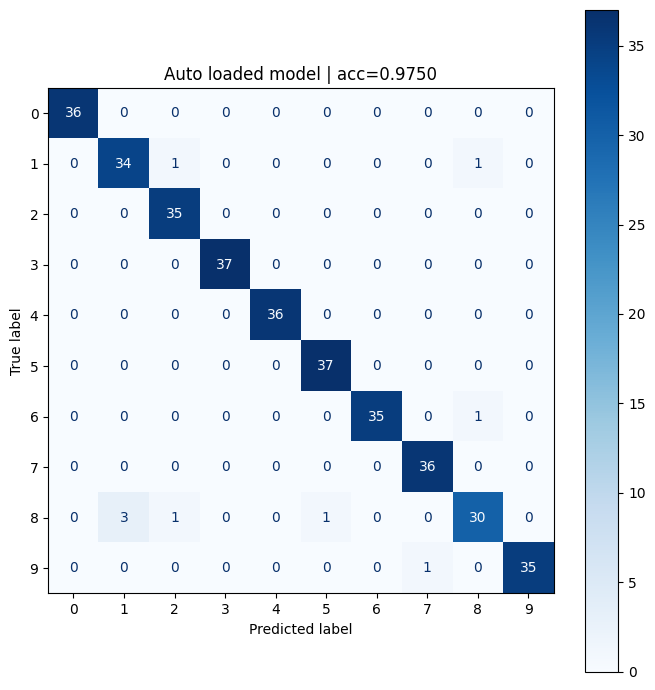

{
  "trial_number": 65,
  "arch_name": "3L_256r_128r_32r",
  "config": [
    [
      256,
      "relu"
    ],
    [
      128,
      "relu"
    ],
    [
      32,
      "relu"
    ]
  ],
  "lr": 0.16416542164064934,
  "batch_size": 16,
  "epochs": 80,
  "best_validation_accuracy": 0.9833333333333333,
  "model_path": "students/kudryavcev/lesson3/models/auto/20260406_154448_auto_3L_256r_128r_32r_lr0.164165_bs16_ep80_acc0.9750.npz",
  "study_db_path": "students/kudryavcev/lesson3/results/lesson3_auto_search_v1.db",
  "test_accuracy": 0.975,
  "loaded_test_accuracy": 0.975
}


In [6]:
final_auto_model = build_model(
    best_hidden_layers,
    input_dim=int(X_trainval_norm.shape[1]),
    output_dim=N_CLASSES,
    seed=FINAL_SEED,
)
final_auto_loss = Exercise.create_cross_entropy_loss()
Exercise.train_model(
    model=final_auto_model,
    loss=final_auto_loss,
    x=X_trainval_norm,
    y=y_trainval,
    lr=best_lr,
    n_epoch=MAX_EPOCHS,
    batch_size=best_batch_size,
    shuffle=True,
)

auto_test_pred = predict_classes(final_auto_model, X_test_norm)
auto_test_accuracy = float(accuracy_score(y_test, auto_test_pred))
auto_arch_name = format_architecture_name(best_hidden_layers)

auto_model_path = make_model_path(
    'auto',
    auto_arch_name,
    lr=best_lr,
    batch_size=best_batch_size,
    epochs=MAX_EPOCHS,
    accuracy=auto_test_accuracy,
)
save_model_bundle(
    final_auto_model,
    auto_model_path,
    arch_name=auto_arch_name,
    config=best_hidden_layers,
    mean_vector=mean,
    std_vector=std,
)

loaded_auto_model, loaded_auto_metadata = load_model_bundle(
    auto_model_path,
    seed=FINAL_SEED,
)
loaded_mean = cast(np.ndarray, loaded_auto_metadata['mean'])
loaded_std = cast(np.ndarray, loaded_auto_metadata['std'])
X_test_from_file = (X_test - loaded_mean) / loaded_std
auto_loaded_pred = predict_classes(loaded_auto_model, X_test_from_file)
auto_loaded_test_accuracy = float(accuracy_score(y_test, auto_loaded_pred))
plot_confusion(
    y_test,
    auto_loaded_pred,
    title=f'Auto loaded model | acc={auto_loaded_test_accuracy:.4f}',
)

auto_best_payload = {
    'trial_number': int(best_trial.number),
    'arch_name': auto_arch_name,
    'config': best_hidden_layers,
    'lr': best_lr,
    'batch_size': best_batch_size,
    'epochs': MAX_EPOCHS,
    'best_validation_accuracy': best_trial_value,
    'model_path': str(auto_model_path),
    'study_db_path': str(AUTO_DB_PATH),
    'test_accuracy': auto_test_accuracy,
    'loaded_test_accuracy': auto_loaded_test_accuracy,
}
AUTO_BEST_JSON.write_text(
    json.dumps(auto_best_payload, ensure_ascii=False, indent=2),
    encoding='utf-8',
)

print(json.dumps(auto_best_payload, ensure_ascii=False, indent=2))
